# DSCI235 Final Project
**Stella Kaulbach** and **Tucker Sussenbach**

Github: https://github.com/sussenbachtucker/DSCI235-Term-Project



### Introduction

For this project, we are going to be analyzing a portion of the 2022 Environmental Performance Index (EPI) report which ranks 180 countries on various performance indicators related to environmental health, ecosystem vitality, and climate change. We will focus on the environmental health data, which includes 13 performance indicators specifically focused on quantifying the air quality, sanitation and drinking water, heavy metal (lead) exposure, and waste management of each country over time For each indicator. Each indicator is a score from 0-100 on how that country performed on that particular metric. The scores were generated by the University of Columbia based on applying specific transformations to each metric; for more information, see the Technical Appendix in the repository. 

This data is publicly available in the [EARTHDATA](https://www.earthdata.nasa.gov/) website, which is the portal for the Earth Science Data Systems (ESDS) Program, providing open access to NASA’s archive of Earth science data. Throuhgout this report, we will make use of the information provided in the Technical Appendix, included when you download the data. We have included this pdf in the files on the github repository under the name "2022-epi-technical-appendix.pdf". 

The structure of the data is as follows: there are 13 CSV files, each one focusing on a particular performance indicator for environmental health. A CSV file for a given performance indicator contains a country’s name, ISO code (both the 3 digit abbreviation and the number), and the EPI score for that country for the given performance indicator for years between 1995 and 2022 (inclusive). The way that the data is compiled allows for comparisons of a country over time and countries with each other. 

The main goal of our analysis will be to combine these 13 performance indicators into a single rating for each country in a given year that will quantify the overall environmental health of that country at that time. We would also like to quantify the overall change in environmental health for each country between 1995 and 2022. Then, we will analyze the resulting ratings and rates of change to see if there are any noticable patterns, contries of significance, or unusual outliers. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data Organization and Cleaning

For our main data structure, we chose to use a MultiIndex dataframe to hold all our datapoints. The MultiIndex allows us to access our data in several different manners, making it very easy to do analysis by country, year, or indicator (or a combination of those). Thus, we have `all_data`, which holds every datapoint and can be indexed in several different ways. 

In [3]:
indicators = ["PMD", "HAD", "OZD", "NOE", "SOE", "COE", "VOE", "USD", "UWD", "PBD", "MSW", "REC", "OCP"]
datasets = []

for x in indicators:
    x_init = pd.read_csv("HLT\\"+x+"_ind_na.csv")
    
    x_long = x_init.melt(id_vars=["code", "iso", "country"], var_name="indicator_year", value_name="value") 
    
    x_long["indicator"] = x
    x_long["year"] = x_long["indicator_year"].str[-4:].astype(int)
    
    x_long = x_long.drop(columns=["indicator_year"])
    
    datasets.append(x_long)
    
all_data = pd.concat(datasets, ignore_index=True)

all_data = all_data.set_index(["code", "iso", "year", "indicator"]).sort_index()

all_data

country      value
code iso year indicator                        
4    AFG 1995 COE        Afghanistan  46.499051
              HAD        Afghanistan   0.000000
              MSW        Afghanistan   1.060000
              NOE        Afghanistan  45.528483
              OCP        Afghanistan        NaN
...                              ...        ...
894  ZMB 2022 REC             Zambia  12.630000
              SOE             Zambia  43.907576
              USD             Zambia  13.924561
              UWD             Zambia  13.248474
              VOE             Zambia  12.812337

[80080 rows x 2 columns]

We also felt that it would be necessary to search for the numeric code associated with each country, so we created `iso_dict` is a dictionary that holds the name of each country as the key and then its corresponding numeric code as a value.

In [4]:
iso_dict = all_data["country"].droplevel(("year", "indicator"))
iso_dict = iso_dict.reorder_levels(["code", "iso"]).index
iso_dict = dict(zip(all_data["country"], iso_dict.get_level_values("code")))
iso_dict

{'Afghanistan': 4,
 'Albania': 8,
 'Algeria': 12,
 'Andorra': 20,
 'Angola': 24,
 'Antigua and Barbuda': 28,
 'Azerbaijan': 31,
 'Argentina': 32,
 'Australia': 36,
 'Austria': 40,
 'Bahamas': 44,
 'Bahrain': 48,
 'Bangladesh': 50,
 'Armenia': 51,
 'Barbados': 52,
 'Belgium': 56,
 'Bermuda': 60,
 'Bhutan': 64,
 'Bolivia': 68,
 'Bosnia and Herzegovina': 70,
 'Botswana': 72,
 'Brazil': 76,
 'Belize': 84,
 'Solomon Islands': 90,
 'British Virgin Islands': 92,
 'Brunei Darussalam': 96,
 'Bulgaria': 100,
 'Myanmar': 104,
 'Burundi': 108,
 'Belarus': 112,
 'Cambodia': 116,
 'Cameroon': 120,
 'Canada': 124,
 'Cabo Verde': 132,
 'Cayman Islands': 136,
 'Central African Republic': 140,
 'Sri Lanka': 144,
 'Chad': 148,
 'Chile': 152,
 'China': 156,
 'Taiwan': 158,
 'Colombia': 170,
 'Comoros': 174,
 'Republic of Congo': 178,
 'Dem. Rep. Congo': 180,
 'Cook Islands': 184,
 'Costa Rica': 188,
 'Croatia': 191,
 'Cuba': 192,
 'Cyprus': 196,
 'Czech Republic': 203,
 'Benin': 204,
 'Denmark': 208,
 'Do

### Developing an Overall Environmental Health Rating

In the Technical Appendix, each indicator is given a weight which represents the significance of that particular metric to the category that it is in. For example, the PMD indicator (PM<sub>2.5</sub> Exposure) is given a 47% weight, which means that it is 47% of the AIR (Air Quality) category. Since we eventually want to have a single score that measures overall Environmental Health (HTL) of a given country, we need to get the weights of each performance indicator in terms of the overall category HLT. 

The below image comes directly from page 3 of the Technical Appendix, and serves as a reference of where the numbers in `weight_indiv` and `weight_group` come from. 

![Subsection of Table from page 3 of Technical Appendix](HLT_Weights.png)

Thus, we multiplied each individual weight (value in `weight_indiv`) by the weight of that category (value in `weight_group`), and then had to do a bit of normalizing to make sure that all the final weights summed to 1. The result is `weight`, which holds a value representing the significance of each performance indicator to the overall category of Environmental Health. 

In [5]:
weight_indiv = pd.Series({"PMD": 0.47, "HAD": 0.38, "OZD": 0.05, "NOE": 0.05, "SOE": 0.02, "COE": 0.02, "VOE": 0.02, "USD": 0.40, "UWD":0.60, "PBD": 1.00, "MSW": 0.50, "REC": 0.25, "OCP": 0.25})
weight_group = pd.Series({"PMD": 0.55, "HAD": 0.55, "OZD": 0.55, "NOE": 0.55, "SOE": 0.55, "COE": 0.55, "VOE": 0.55, "USD": 0.25, "UWD":0.25, "PBD": 0.10, "MSW": 0.10, "REC": 0.10, "OCP": 0.10})

weight = weight_indiv * weight_group
weight /= weight.sum()
weight

PMD    0.257086
HAD    0.207857
OZD    0.027350
NOE    0.027350
SOE    0.010940
COE    0.010940
VOE    0.010940
USD    0.099453
UWD    0.149180
PBD    0.099453
MSW    0.049727
REC    0.024863
OCP    0.024863
dtype: float64

*we might do some analysis on the weight values?*
only if we feel like we don't have enough analysis later

Now that we have the weights assiciated with each indicator, we need to add the weights onto the dataframe for future weighted average computaions. So, we made new 2 columns in the dataframe. `weight` is the actual weight assiciated with each indicator for the overall environmental health rating. Then, we created the `weighted_value` column to represent the value of each indicator with respect to the weight of that indicator

*We created a new dataframe so the original dataframe is unaffected*

In [6]:
weighted_data = all_data.copy()
weighted_data['weight'] = weighted_data.index.get_level_values('indicator').map(weight)
weighted_data['weighted_value'] = weighted_data['value'] * weighted_data['weight']
weighted_data.head()

country      value    weight  weighted_value
code iso year indicator                                                  
4    AFG 1995 COE        Afghanistan  46.499051  0.010940        0.508692
              HAD        Afghanistan   0.000000  0.207857        0.000000
              MSW        Afghanistan   1.060000  0.049727        0.052710
              NOE        Afghanistan  45.528483  0.027350        1.245185
              OCP        Afghanistan        NaN  0.024863             NaN

In order to get a single rating for each country for a given year, we needed to take the weighted average of all the performance indicators using the weights from above. This will give us a single value from 0 - 100 that quatifies the overall environmental health for a country in a given year.

However, not all country has ratings for all 13 indicators, so we need to make sure that our average calculations are accounting for the missing data. To do this, we also keep track of the sum of the weights, and then normalize the averages using their weight sums.

In [7]:
temp_df = weighted_data.dropna(subset=['weighted_value', 'weight']).groupby(level=['code','year']).agg(weighted_sum=('weighted_value', 'sum'), weight_sum=('weight', 'sum'))
temp_df['weighted_avg'] = temp_df['weighted_sum'] / temp_df['weight_sum']
temp_df

weighted_sum  weight_sum  weighted_avg
code year                                        
4    1995     15.250911    0.975137     15.639766
     1996     15.332889    0.975137     15.723835
     1997     15.055237    0.975137     15.439104
     1998     14.846390    0.975137     15.224931
     1999     14.676584    0.975137     15.050795
...                 ...         ...           ...
894  2018     20.816443    0.975137     21.347204
     2019     21.165970    0.975137     21.705643
     2020     21.171291    0.975137     21.711100
     2021     21.171291    0.975137     21.711100
     2022     21.171291    0.975137     21.711100

[6160 rows x 3 columns]

Now that we have our weighted averages, we would like to combine this with parts of original dataframe to have `code` and `country` values also accessible in the same data structure as the weighted averages. Intially, the rows were duplicated several times over because of the structure of the `all_data` dataframe, so we had to do some mindful dropping of duplicate rows to ensure our data was consise.

In [8]:
# doa a choin
weighted_avgs = all_data.droplevel('indicator')
weighted_avgs.drop('value', axis=1, inplace=True)
weighted_avgs = weighted_avgs.join(temp_df, how = "outer")
weighted_avgs.drop(columns=['weighted_sum', 'weight_sum'], inplace=True)
weighted_avgs["year"] = weighted_avgs.index.get_level_values("year")
weighted_avgs.drop_duplicates(inplace=True)
weighted_avgs.drop("year", axis = 1, inplace=True)
weighted_avgs

country  weighted_avg
code iso year                           
4    AFG 1995  Afghanistan     15.639766
         1996  Afghanistan     15.723835
         1997  Afghanistan     15.439104
         1998  Afghanistan     15.224931
         1999  Afghanistan     15.050795
...                    ...           ...
894  ZMB 2018       Zambia     21.347204
         2019       Zambia     21.705643
         2020       Zambia     21.711100
         2021       Zambia     21.711100
         2022       Zambia     21.711100

[6160 rows x 2 columns]

### Analysis of the Environmental Health Rating

Now that we have a single rating for overall environmental health for each country in a given year, we will do some analysis on how the countries compare to one another. We will look at which countries had the best and worst ratings overall (and for our most recent data). Then, we will group countries by their ratings for 1995 and 2022 and see what the most common range of ratings.

**Which countries had the best and worst ratings for all years available?**

In [9]:
sorted_avgs = weighted_avgs.sort_values(by = "weighted_avg")
sorted_avgs.head(10), sorted_avgs.tail(10)

(               country  weighted_avg
 code iso year                       
 356  IND 1998    India      7.748112
          1997    India      7.792811
          1999    India      7.989086
          2000    India      8.083913
          2001    India      8.188146
          1995    India      8.191865
          1996    India      8.216341
          2002    India      8.388171
          2003    India      8.782292
 426  LSO 2013  Lesotho      8.983694,
                country  weighted_avg
 code iso year                       
 246  FIN 2017  Finland     93.139378
 352  ISL 2014  Iceland     93.305664
          2015  Iceland     93.696851
          2016  Iceland     93.708201
          2017  Iceland     94.263508
          2018  Iceland     94.337965
          2019  Iceland     94.432641
          2022  Iceland     94.489211
          2020  Iceland     94.489211
          2021  Iceland     94.489211)

As we can see in the dataframe above, *India* had the 9 of the worst overall ratings (from 1995 to 2003) followed by Lesotho in 2013. Thus, India in the late 1990s and early 2000s was performing worst in terms of overall environmental health. It is important to note that India's rating was fluctuating during that period, as opposed to slowly declining or improving. 


For the overall best ratings, we can see that *Iceland* had the 9 best ratings (from 2014 to 2021), with a slight increase or no change over time. So, Iceland had very good ratings and still continued to improve.

We need more here I just don't know what to say

**Which countries had the best and worst environmental health ratings for 2022?**

In [10]:
sorted_avgs_2022 = sorted_avgs.xs(2022, level = 2)
sorted_avgs_2022.head(10), sorted_avgs_2022.tail(10)

(                           country  weighted_avg
 code iso                                        
 426  LSO                   Lesotho     11.162792
 586  PAK                  Pakistan     11.317140
 356  IND                     India     12.468973
 140  CAF  Central African Republic     13.516145
 120  CMR                  Cameroon     14.473288
 887  YEM                     Yemen     15.156355
 566  NGA                   Nigeria     15.302739
 4    AFG               Afghanistan     16.452548
 624  GNB             Guinea-Bissau     16.779190
 524  NPL                     Nepal     16.904048,
               country  weighted_avg
 code iso                           
 208  DNK      Denmark     85.187352
 124  CAN       Canada     85.577380
 36   AUS    Australia     86.044200
 442  LUX   Luxembourg     86.502758
 372  IRL      Ireland     88.109023
 756  CHE  Switzerland     88.345493
 578  NOR       Norway     91.818733
 752  SWE       Sweden     92.847432
 246  FIN      Finland     93

For the year 2022 (our most recent data available), we can see that the worst rated country overall is *Lesotho*. In general, the 10 countries with the worst ratings are all in Africa (5), South Asia (3), and the Greater Middle East (2). 

In contrast, the 10 countries with the best environmental health ratings are located in Europe (mostly Northern and Western Europe), with the exception of Canada and Australia. The country with the best overall rating is *Iceland*, which is not suprizing as it was listed in the overall best ratings for all time in 2022. 



describe plot purpose

Text(0, 0.5, 'Number of Countries')

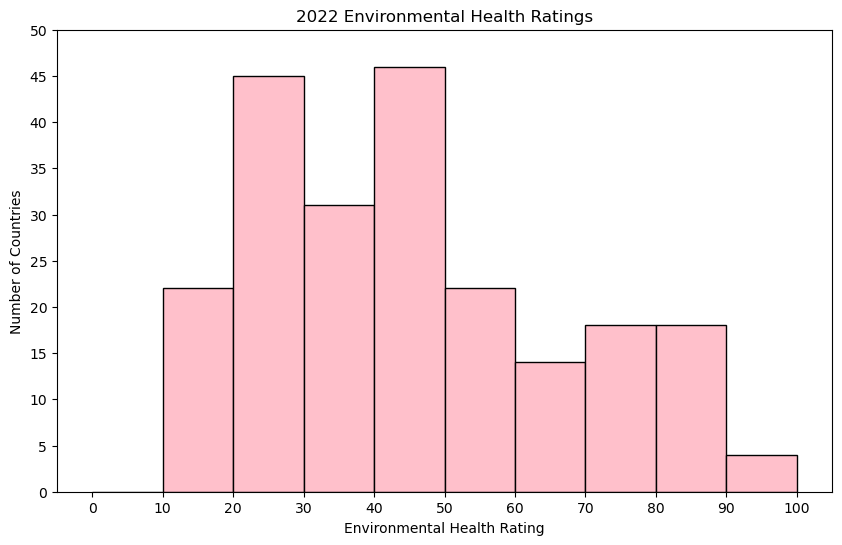

In [11]:
# Plot the rate of each country
most_recent_avgs = weighted_avgs.droplevel("iso").reorder_levels(["year", "code"]).loc[2022]

fig, ax = plt.subplots(figsize = (10, 6))

ax.hist(most_recent_avgs["weighted_avg"], bins = np.linspace(0, 100, 11), color = "pink", edgecolor = "black")
ax.set_xticks(np.linspace(0, 100, 11))
ax.set_yticks(np.linspace(0,50,11))
ax.set_title("2022 Environmental Health Ratings")
ax.set_xlabel("Environmental Health Rating")
ax.set_ylabel("Number of Countries")

From the above graph, we can determine that a large number of countries have a environmental health rating between 40 and 50, and nearly as many countries have a rating between 20 and 30. 

For the countries with a rating of 90 - 100, the graph demonstrates that there are very few, and the data just above on the best rated countries can confirm that there are exactly 4: Norway, Sweden, Finland, and Iceland. It is interesting to note that these countries are all Nordic countries ........

more


### Developing a Rate of Change Quantifyer: Total Difference Rate

Beyond just the weighted average, we also wanted to quantify the overall change the each country has overgone for all the years where data is available. So, we found a rate of change for the weighted averages by taking the difference of most recent year and the oldest year and then dividing by the number of years. 

This information allows us to quantify overall improvement in environmental health over time.

In [12]:
# Find total difference for each county and divide by years to get the rate
def total_diff(country):
    country["total_diff_rate"] = ((country.iloc[-1].weighted_avg) - (country.iloc[0].weighted_avg)) / len(country)
    return country

weighted_avgs_2 = weighted_avgs.groupby('code').apply(total_diff)
weighted_avgs_total = weighted_avgs_2.droplevel(0)
weighted_avgs_total

country  weighted_avg  total_diff_rate
code iso year                                            
4    AFG 1995  Afghanistan     15.639766         0.029028
         1996  Afghanistan     15.723835         0.029028
         1997  Afghanistan     15.439104         0.029028
         1998  Afghanistan     15.224931         0.029028
         1999  Afghanistan     15.050795         0.029028
...                    ...           ...              ...
894  ZMB 2018       Zambia     21.347204         0.108386
         2019       Zambia     21.705643         0.108386
         2020       Zambia     21.711100         0.108386
         2021       Zambia     21.711100         0.108386
         2022       Zambia     21.711100         0.108386

[6160 rows x 3 columns]

### Analysis of Total Difference Rate

description of what we want to look at:


**Which countries have the largest and smallest difference rates? Are there any countries with a non-positive difference rate?**

In [13]:
total_diff_only = weighted_avgs_total.droplevel("year").drop("weighted_avg", axis = 1).drop_duplicates()
total_diff_only.sort_values(by = "total_diff_rate", inplace=True)
total_diff_only.head(10), total_diff_only.tail(10)

(                  country  total_diff_rate
 code iso                                  
 426  LSO          Lesotho        -0.126526
 148  TCD             Chad        -0.098989
 732  ESH   Western Sahara        -0.097522
 716  ZWE         Zimbabwe        -0.090062
 90   SLB  Solomon Islands        -0.062984
 854  BFA     Burkina Faso        -0.051480
 586  PAK         Pakistan        -0.042334
 533  ABW            Aruba        -0.033694
 540  NCL    New Caledonia        -0.024735
 508  MOZ       Mozambique        -0.023636,
               country  total_diff_rate
 code iso                              
 462  MDV     Maldives         0.646360
 440  LTU    Lithuania         0.651181
 400  JOR       Jordan         0.665644
 196  CYP       Cyprus         0.668589
 792  TUR       Turkey         0.670747
 410  KOR  South Korea         0.724446
 702  SGP    Singapore         0.759739
 620  PRT     Portugal         0.770520
 372  IRL      Ireland         0.831099
 233  EST      Estonia         

In [14]:
num_neg = total_diff_only[total_diff_only["total_diff_rate"] < 0].count()
print(f"There are {num_neg.values[0]} countries with a negative difference rate in environmental health")

There are 23 countries with a negative difference rate in environmental health


Our first observation about the 10 lowest difference rates was that they were all negative. We had initially assumed that the lowest difference rates would be close to 0 but that they would all be positive. Not only are all the lowest rates negative, there are actually a total of 23 countries with a negative rate of change for their environmental health rating from 1995 to 2022. This was a shockingly high number and highlights the fact that many people throught the world face worsening environmental health conditions.

Maybe some analysis about what all the lowest 10 countries have in common (like region)


Conversly, the countries with the 10 highest difference rates were all between 0.64 and 0.86, which is a suprisingly high rate of improvement. It is interesting to see *Ireland* in both this list and the highest overall ratings in 2022 list, indicating that Ireland has both high rate of improvement and a high rating. 

However, the highest improvement rate was *Estonia*, which .....

more ^

**We also want to look at a scatterplot of weighted averages and total changes**

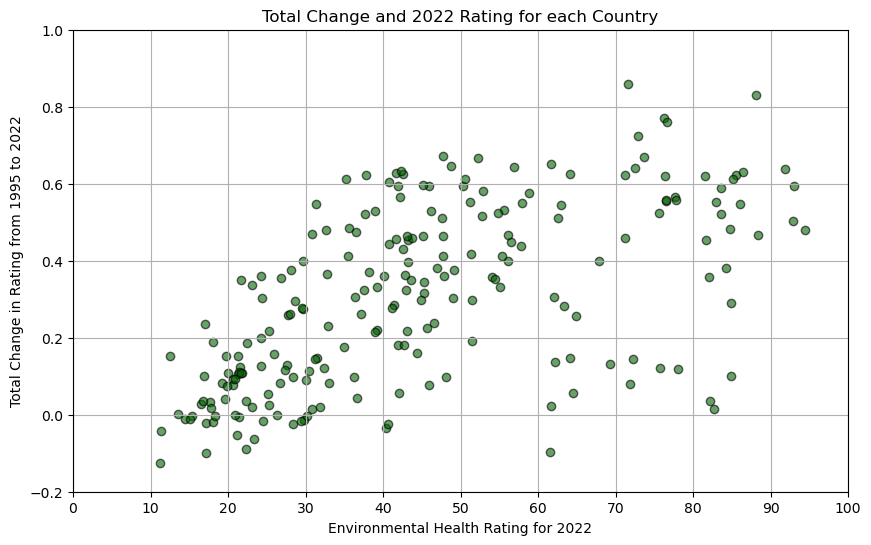

In [15]:
fig, ax = plt.subplots(figsize = (10, 6))

most_recent_avgs_total = weighted_avgs_total.xs(2022, level = 2)

ax.scatter(most_recent_avgs_total["weighted_avg"], most_recent_avgs_total["total_diff_rate"], color = "darkgreen", edgecolors="black", alpha=.60)

ax.set_xlabel("Environmental Health Rating for 2022")
ax.set_ylabel("Total Change in Rating from 1995 to 2022")
ax.set_title("Total Change and 2022 Rating for each Country")

ax.set_xticks(np.linspace(0,100,11))
ax.set_yticks(np.linspace(-0.2, 1, 7))

ax.grid(visible=True)

analysis of graph
- many countries in the low improvement, low rating
- many near the center
- NONE in the high improvement, low rating section which makes sense with our data (sanity check)
- several in the low improvement, high rating section (which also makes sense if they started out good and just stayed there)


- would like to find the one dot just above a rating of 60 that has a negative rate of change

### Analysis of Impact of Paris Climate Agreement on Rate of Change for Environmental Health

In this section, we wanted to segment our data into before and after the Paris Climate Agreement was signed on April 22, 2016. 

The Paris Climate Agreement was an international treaty aimed at limiting the global average temperature increase to 1.5°C by reducing the participating countries' greenhouse gas emmissions. It entered into force in November 2016. **should add more and the source here**

Our goal is to analyze whether there is a notable difference between the environmental health rate of change before and after 2016 (when the Paris Climate Agreement went into effect). We will separately look at the countries that did and did not participate in the agreement, and see if there is a significant difference between those groups as well.

We realized that we would need to start by getting a list of which countries were actually invovled in the Paris Climate Agreement, so we pulled data from a United Nations website to give us a list of those countries. We had to convert the list into a csv ourselves, but we did not alter the data in any way. You can find the csv file titled "ParisCountries.csv" in the repository.


In [16]:
paris_countries = pd.read_csv("ParisCountries.csv", usecols=["country"])
paris_countries

,country
0,Afghanistan
1,Albania
2,Algeria
3,Andorra
4,Angola
...,...
170,Uruguay
171,Vanuatu
172,Venezuela (Bolivarian Republic of)
173,Viet Nam


description of what the below code does

In [37]:
# Find difference from start-2016 and 2016-end for paris and divide by #years to get rate
def before_diff(country):
    idx = pd.IndexSlice
    years = country.index.get_level_values(-1)
    years_before = (years < 2016).sum()
    country["before_PCA_diff"] = ((country.loc[idx[:,:,2016]].weighted_avg) - (country.iloc[0].weighted_avg)) / years_before
    return country

def after_diff(country):
    idx = pd.IndexSlice
    years = country.index.get_level_values(-1)
    years_after = (years > 2016).sum()
    country["after_PCA_diff"] = ((country.iloc[-1].weighted_avg) - (country.loc[idx[:,:,2016]].weighted_avg)) / years_after
    return country


temp_diff = weighted_avgs.groupby('code').apply(before_diff).droplevel(0)
paris_diff2 = temp_diff.groupby('code').apply(after_diff)
paris_diff = paris_diff2.droplevel(0)

# Need to get the diff between before and after here
paris_diff['PCA_diff'] = paris_diff['after_PCA_diff'] - paris_diff['before_PCA_diff']

paris_diff_in = paris_diff[paris_diff["country"].isin(paris_countries.country)] #countries that signed the Paris Climate Agreement in 2016
paris_diff_out = paris_diff[~paris_diff["country"].isin(paris_countries.country)] #countries that did NOT sign the Paris Climate Agreement
# paris_diff_in, paris_diff_out

In [28]:
# Find the difference between those two rate and look for changes
paris_in_mean = paris_diff_in['PCA_diff'].mean()
paris_out_mean = paris_diff_out['PCA_diff'].mean()

print(f"Countries in the Paris Climate Agreement changed by an average of {paris_in_mean}.\nCountries outside the Paris Climate Agreement changed by an average of {paris_out_mean}.")

Countries in the Paris Climate Agreement changed by an average of -0.18875889302319052.
Countries outside the Paris Climate Agreement changed by an average of -0.07773716586274404.


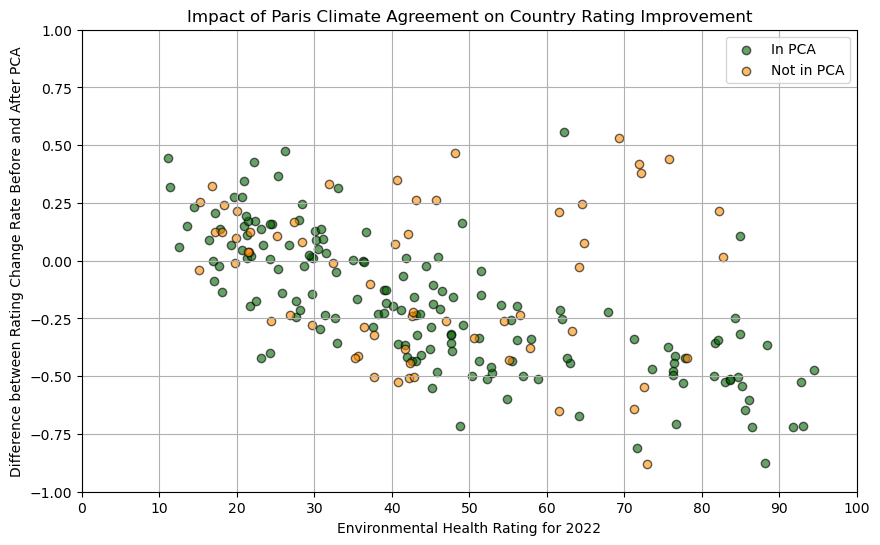

In [36]:
# Plot the diff and see if the Paris CA did anything
fig, ax = plt.subplots(figsize=(10, 6))
paris_diff_in_2022 = paris_diff_in.xs(2022, level=2)
paris_diff_out_2022 = paris_diff_out.xs(2022, level=2)
ax.scatter(paris_diff_in_2022['weighted_avg'], paris_diff_in_2022['PCA_diff'], color = "darkgreen", edgecolors="black", alpha=.60, label="In PCA")
ax.scatter(paris_diff_out_2022['weighted_avg'], paris_diff_out_2022['PCA_diff'], color = "darkorange", edgecolors="black", alpha=.60, label="Not in PCA")
ax.set_xlabel("Environmental Health Rating for 2022")
ax.set_ylabel("Difference between Rating Change Rate Before and After PCA")
ax.set_title("Impact of Paris Climate Agreement on Country Rating Improvement")

ax.set_xticks(np.linspace(0,100,11))
ax.set_yticks(np.linspace(-1, 1, 9))
ax.legend()

ax.grid(visible=True)

From the above data, we can see that countries within the Paris Climate Agreeement have been improving slower after the agreement then before the agreement. We can also see that the same holds true for counries not within the Paris Climate Agreement, but they are much closer to having the same rate of improvement before and after the Paris Climate Agreement.

Based on the graph, we can inder that the closer a country comes to achieving an enviromental health rating of 100, the lower their rate of growth becomes, which matches the intuition that there is less total room for improvement the closer the rating is to 100. We see a general clustering for countries with Environmental Health ratings below 30, as most have them have improved more after the Paris Climate Agreement was signed than before it was signed, no matter if they were in the Paris Climate Agreement or not; however, the highest improving countries after the Paris Climate Agreement are all within the agreement. It is also important to note that all of the highest rated countries are in the Paris Climate Agreement and all of the countries in the agreement are much more compact and follow a smooth line compared to countries not in the Paris Climate Agreement, which are much more spread out.

Interestingly enough, there is a large cluster of countries with a rating around 70-80 that have improved faster after the agreement was signed that before, but are all not in the Paris Climate Agreement. While these countries may not have signed the Paris Climate Agreement, there may have been pressure from the agreement to improve their environmental health from the existence of the agreement altogether, even if they couldn't sign it for certain geopolitcal reasons. Overall, it seems that the Paris Climate Agreement is mostly targeted at countries with low Environmental Heath ratings and helping them towards a higher rating following a proven path from higher rated countries.

### Specific Country Analysis

Graphic of US DALY indicators over time


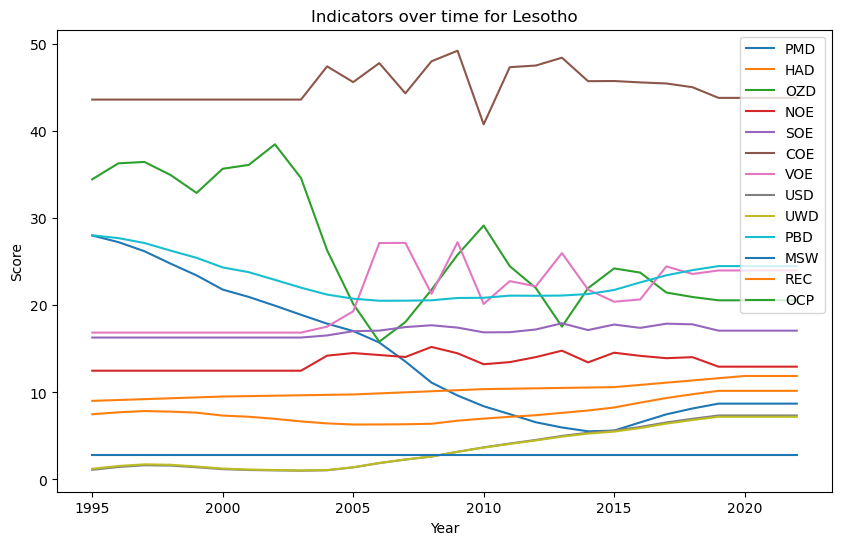

In [38]:
# get the numeric iso code for Lesotho, Estonia, Ireland
LES_num = iso_dict.get("Lesotho")
LES_data = all_data.loc[LES_num].value


plt.figure(figsize=(10, 6))
for p_i in indicators:
    plt.plot(LES_data.droplevel("iso").reorder_levels(["indicator", "year"]).loc[p_i], label = p_i)


plt.xlabel("Year")
#plt.xticks(years)
plt.ylabel("Score")
plt.title("Indicators over time for Lesotho") 
plt.legend()

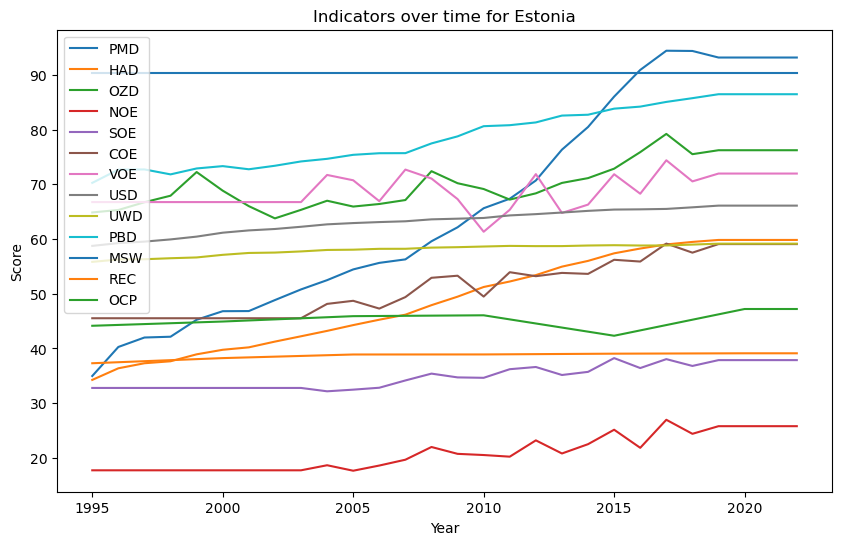

In [39]:
# get the numeric iso code for Lesotho, Estonia, Ireland
EST_num = iso_dict.get("Estonia")
EST_data = all_data.loc[EST_num].value


plt.figure(figsize=(10, 6))
for p_i in indicators:
    plt.plot(EST_data.droplevel("iso").reorder_levels(["indicator", "year"]).loc[p_i], label = p_i)


plt.xlabel("Year")
#plt.xticks(years)
plt.ylabel("Score")
plt.title("Indicators over time for Estonia") 
plt.legend()

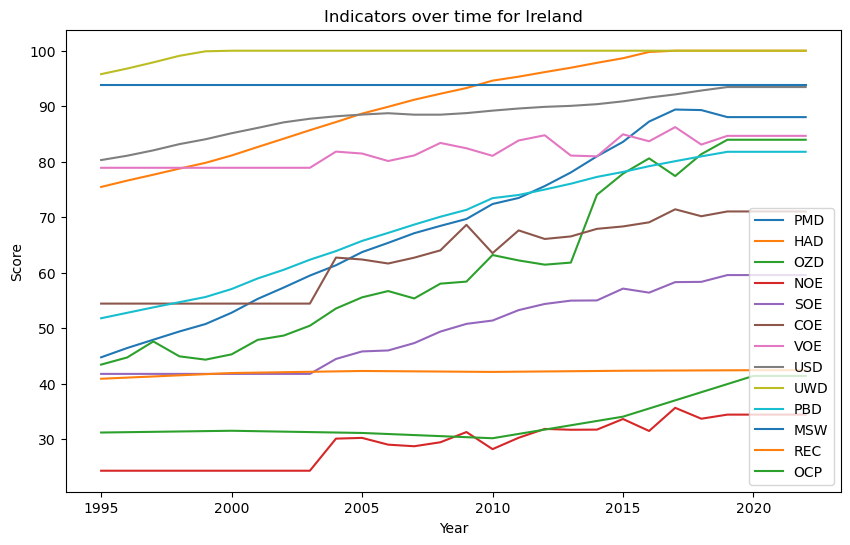

In [40]:
# get the numeric iso code for Lesotho, Estonia, Ireland
IRE_num = iso_dict.get("Ireland")
IRE_data = all_data.loc[IRE_num].value


plt.figure(figsize=(10, 6))
for p_i in indicators:
    plt.plot(IRE_data.droplevel("iso").reorder_levels(["indicator", "year"]).loc[p_i], label = p_i)


plt.xlabel("Year")
#plt.xticks(years)
plt.ylabel("Score")
plt.title("Indicators over time for Ireland") 
plt.legend()

We wanted to take a look at the change of each score for three specific countries: Lesotho, Estonia, and Ireland, to get a general idea of how these factors change for three specific kinds of scenarios.

For Lesotho, we wanted look at country that had one of the lowest 2022 ratings, as well as the lowest total difference between rating in 1995 and rating in 2022.

For Estonia, we wanted.

For Ireland, we 

### Conclusion